In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lobster import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [157]:
message_csv  = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_csv = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"


msg, ob, qr, df = load_lobster_data(
    message_csv,
    orderbook_csv,
    levels=10,
    K=5
)

/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/i

In [158]:
aes = compute_aes_by_level(df, K=5)
df_norm = normalize_by_aes(df, aes, K=5) 

In [159]:
def shift_orderbook_before_event(df, K):

    df_shift = df.copy()

    for i in range(1, K+1):

        df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
        df_shift[f"Q_-{i}"] = df_shift[f"Q_-{i}"].shift(1)

    return df_shift


df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)

In [ ]:
# Apply log(1+q) transform to queue sizes
def log_transform_queues(df, K):

    df = df.copy()

    for i in range(1, K+1):
        df[f"Q_{i}"] = np.log1p(df[f"Q_{i}"])
        df[f"Q_-{i}"] = np.log1p(df[f"Q_-{i}"])

    return df


df_qr = log_transform_queues(df_qr, K=5)

In [ ]:
# Build additional MDQR state variables:
# - spread at the best prices
# - trade imbalance from bid and ask queue volumes
# - hour of the day

def add_mdqr_features(df, K):

    df = df.copy()

    df["spread"] = df["P_1"] - df["P_-1"]

    bid_cols = [f"Q_-{i}" for i in range(1, K+1)]
    ask_cols = [f"Q_{i}" for i in range(1, K+1)]

    V_bid = df[bid_cols].sum(axis=1)
    V_ask = df[ask_cols].sum(axis=1)

    df["trade_imbalance"] = (V_bid - V_ask) / (V_bid + V_ask + 1e-8)

    df["hour"] = (df["time"] // 3600).astype(int)

    return df


df_qr = add_mdqr_features(df_qr, K=5)

In [ ]:
#keep only the variable needed for the event by event MDQR sequence

def build_mdqr_sequence(df, K):

    q_cols = []

    for i in range(1, K+1):
        q_cols.append(f"Q_-{i}")

    for i in range(1, K+1):
        q_cols.append(f"Q_{i}")

    seq = df[
        ["type",
         "lvl",
         "size",
         "dtk",
         "spread",
         "trade_imbalance",
         "hour"]
        + q_cols
    ].copy()

    seq = seq.reset_index(drop=True)

    return seq


mdqr_seq = build_mdqr_sequence(df_qr, K=5)

In [ ]:
# si je comprends bien dans x_k il y a les previous-event features donc on ajoute:
# - previous event type
# - previous event level
# - previous event size

def add_previous_event_features(seq):

    df = seq.copy()

    df["omega_prev"] = df["type"].shift(1)
    df["level_prev"] = df["lvl"].shift(1)
    df["size_prev"] = df["size"].shift(1)

    return df


mdqr_seq = add_previous_event_features(mdqr_seq)

In [ ]:
def add_mdqr_categorical_features(df, K):
    """
    Add only the categorical features from the paper:
    - omega: current event type code {L:0, C:1, M:2}  (needed for targets / size model)
    - hour_idx: categorical hour index
    - e_i: last event type at each level i before current event
    """
    out = df.copy()

    event_map = {"L": 0, "C": 1, "M": 2}
    pad_code = 3

    # current event type (kept for targets and size model conditioning)
    out["omega"] = out["type"].map(event_map).astype(int)

    # remove first row with no previous global event info if needed
    out = out[out["type"].notna()].copy()

    # categorical hour index
    unique_hours = sorted(out["hour"].dropna().unique().tolist())
    hour_to_idx = {h: i for i, h in enumerate(unique_hours)}
    out["hour_idx"] = out["hour"].map(hour_to_idx).astype(int)

    # level-wise last event type e_i(t_k)
    levels = list(range(-K, 0)) + list(range(1, K + 1))

    for lvl in levels:
        col = f"e_{lvl}"

        cur_lvl_event = np.where(out["lvl"] == lvl, out["omega"], np.nan)
        last_lvl_event = pd.Series(cur_lvl_event, index=out.index).ffill().shift(1)

        out[col] = last_lvl_event.fillna(pad_code).astype(int)

    out = out.reset_index(drop=True)
    return out, hour_to_idx

In [165]:
mdqr_seq, hour_to_idx = add_mdqr_categorical_features(mdqr_seq, K=5)

In [ ]:
# Split the state vector into:
# - numerical features
# - level-wise categorical features e_i(t_k)
# - categorical hour feature

def build_mdqr_state_components(df, K):
    q_cols = [f"Q_-{i}" for i in range(1, K+1)] + [f"Q_{i}" for i in range(1, K+1)]
    e_cols = [f"e_{i}" for i in list(range(-K, 0)) + list(range(1, K+1))]

    # numerical features 
    X_num = df[q_cols + ["spread", "trade_imbalance"]].copy()

    # categorical features with embeddings
    X_cat_levels = df[e_cols].copy()
    X_cat_hour = df["hour_idx"].copy()

    return X_num, X_cat_levels, X_cat_hour


X_num, X_cat_levels, X_cat_hour = build_mdqr_state_components(mdqr_seq, K=5)

In [ ]:
# Encode each (event type, price level) pair as one class in {0,...,3*2K-1}.
# For K=5, this gives 30 event-level classes.

def encode_event_level(event, level, K=5):

    level = int(level)

    side_offset = 0 if level < 0 else K

    level_index = abs(level) - 1

    return event * (2*K) + side_offset + level_index

In [ ]:
# Build the target y_event_level corresponding to the observed class
# (event type, level) for each row in the MDQR sequence.

def build_mdqr_targets(df, K=5):

    y_event_level = []

    for e,l in zip(df["omega"], df["lvl"]):
        y_event_level.append(encode_event_level(e,l,K))

    y_event_level = np.array(y_event_level)

    return y_event_level


y_event_level = build_mdqr_targets(mdqr_seq)

In [ ]:
# Discretize order sizes into quantile-based bins.
# This transforms the size model into a classification problem.

def build_size_bins(size_series, n_bins=200):

    bins = pd.qcut(size_series, q=n_bins, duplicates="drop")

    labels = bins.cat.codes

    return labels, bins


size_classes, size_bins = build_size_bins(mdqr_seq["size"])

mdqr_seq["size_class"] = size_classes

In [ ]:
class IntensityNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        emb_dim_level=2,
        emb_dim_hour=2,
        output_dim=30
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)   # L,C,M,PAD
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = num_numeric_features + num_level_cats * emb_dim_level + emb_dim_hour

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, output_dim),
            nn.ReLU()
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        x = torch.cat([x_num, lvl_emb, hour_emb], dim=1)
        return self.net(x)

In [ ]:
class SizeNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        emb_dim_level=2,
        emb_dim_hour=2,
        num_classes=200
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = num_numeric_features + num_level_cats * emb_dim_level + emb_dim_hour + 2

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour, omega_cur, lvl_cur):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        extra = torch.stack([omega_cur.float(), lvl_cur.float()], dim=1)
        x = torch.cat([x_num, lvl_emb, hour_emb, extra], dim=1)
        return self.net(x)

In [171]:
def intensity_loss(lam,y,dt):

    lam_sum = lam.sum(dim=1)

    lam_event = lam[torch.arange(len(y)),y]

    loss = -(torch.log(lam_event+1e-8)-lam_sum*dt)

    return loss.mean()


size_loss = nn.CrossEntropyLoss()

In [ ]:
# Build the dataset and dataloader used for stochastic mini-batch training.

class MDQRDataset(Dataset):

    def __init__(self, X_num, X_cat_levels, X_cat_hour, df, K=5):

        X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

        self.x_num = torch.tensor(
            X_num_clean.values.astype(np.float32),
            dtype=torch.float32
        )

        self.x_cat_levels = torch.tensor(
            X_cat_levels_clean.values.astype(np.int64),
            dtype=torch.long
        )

        self.x_cat_hour = torch.tensor(
            X_cat_hour.values.astype(np.int64),
            dtype=torch.long
        )

        self.dt = torch.tensor(
            df["dtk"].astype(float).values,
            dtype=torch.float32
        )

        self.y_event_level = torch.tensor(
            build_mdqr_targets(df, K=K),
            dtype=torch.long
        )

        self.y_size = torch.tensor(
            df["size_class"].astype(int).values,
            dtype=torch.long
        )

        self.omega_cur = torch.tensor(
            df["omega"].astype(int).values,
            dtype=torch.long
        )

        self.lvl_cur = torch.tensor(
            df["lvl"].astype(int).values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        return (
            self.x_num[idx],
            self.x_cat_levels[idx],
            self.x_cat_hour[idx],
            self.y_event_level[idx],
            self.y_size[idx],
            self.dt[idx],
            self.omega_cur[idx],
            self.lvl_cur[idx]
        )

In [173]:
dataset = MDQRDataset(X_num, X_cat_levels, X_cat_hour, mdqr_seq, K=5)

loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True
)

In [174]:
num_numeric_features = X_num.shape[1]
num_level_cats = X_cat_levels.shape[1]
num_hour_classes = mdqr_seq["hour_idx"].nunique()

model_intensity = IntensityNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    emb_dim_level=2,
    emb_dim_hour=2,
    output_dim=30
)

model_size = SizeNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    emb_dim_level=2,
    emb_dim_hour=2,
    num_classes=200
)

In [ ]:
#training of the two MDQR components
# The total loss is:
# - Poisson negative log-likelihood for event/time
# - cross-entropy for order size classification
loss_history = []

opt = optim.Adam(
    list(model_intensity.parameters()) +
    list(model_size.parameters()),
    lr=1e-4
)

for epoch in range(80):

    total_loss = 0.0

    for x_num_b, x_cat_levels_b, x_cat_hour_b, y_ev, y_sz, dt_b, omega_cur_b, lvl_cur_b in loader:

        lam = model_intensity(x_num_b, x_cat_levels_b, x_cat_hour_b)
        loss_int = intensity_loss(lam, y_ev, dt_b)

        size_logits = model_size(
            x_num_b,
            x_cat_levels_b,
            x_cat_hour_b,
            omega_cur_b,
            lvl_cur_b
        )
        loss_size_val = size_loss(size_logits, y_sz)

        loss = loss_int + loss_size_val

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    loss_history.append(total_loss)
    print(epoch, total_loss)

0 3651.9164502620697
1 2534.6460342407227
2 2325.2482359409332
3 2203.107360601425
4 1932.0000922083855
5 428.0856535434723
6 384.2242677807808
7 348.15420734882355
8 330.35450145602226
9 301.1903869062662
10 268.14945481717587
11 246.02478377521038
12 226.04744131863117
13 221.024875998497
14 193.42724145948887
15 176.10318264365196
16 164.0521254092455
17 150.35119879245758
18 139.8481347411871
19 130.22432285547256
20 120.396200761199
21 113.75963407754898
22 100.84422527253628
23 102.73248760402203
24 85.74413068592548
25 89.87840642035007
26 80.8501710742712
27 69.04204700887203
28 60.569130808115005
29 54.06842891871929
30 48.05792444944382
31 41.93101844191551
32 44.892956748604774
33 35.9281105697155
34 27.078171774744987
35 28.919611498713493
36 27.48178832232952
37 16.197922959923744
38 10.250598818063736
39 6.681183323264122
40 8.61865322291851
41 0.6074149459600449
42 -3.9706947654485703
43 -6.521575301885605
44 -10.626642301678658
45 -12.496345803141594
46 -12.729718863964

In [ ]:
# Plot training loss 
plt.figure(figsize=(8,5))

plt.plot(loss_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (MDQR)")
plt.grid(True)

plt.show()

In [ ]:
# Rebuild the full state tensors

X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

x_num_tensor = torch.tensor(
    X_num_clean.values.astype(np.float32),
    dtype=torch.float32
)

x_cat_levels_tensor = torch.tensor(
    X_cat_levels_clean.values.astype(np.int64),
    dtype=torch.long
)

x_cat_hour_tensor = torch.tensor(
    X_cat_hour.values.astype(np.int64),
    dtype=torch.long
)

model_intensity.eval()
with torch.no_grad():
    lam = model_intensity(
        x_num_tensor,
        x_cat_levels_tensor,
        x_cat_hour_tensor
    ).cpu().numpy()

In [178]:
#construction transition matrix 

EVENTS = [
    "cancel_ask",
    "cancel_bid",
    "limit_ask",
    "limit_bid",
    "trade_ask",
    "trade_bid"
]

def label_event(row):
    """
    Map historical event (type, lvl) -> one of the 6 labels:
    cancel_ask, cancel_bid, limit_ask, limit_bid, trade_ask, trade_bid

    Convention in your preprocessing:
    - L/C: lvl > 0 => ask, lvl < 0 => bid
    - M:   lvl < 0 => trade_ask, lvl > 0 => trade_bid
    """
    t = row["type"]
    lvl = row["lvl"]

    if t == "L":
        base = "limit"
        side = "ask" if lvl > 0 else "bid"

    elif t == "C":
        base = "cancel"
        side = "ask" if lvl > 0 else "bid"

    elif t == "M":
        base = "trade"
        side = "ask" if lvl < 0 else "bid"

    else:
        raise ValueError(f"Unknown event type: {t}")

    return f"{base}_{side}"

In [179]:
def row_normalize(counts):
    """
    Robust row normalization:
    if a row sum is zero, return zeros instead of NaN.
    """
    row_sums = counts.sum(axis=1)
    return counts.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

In [ ]:
# 1) Real transition matrix

d = mdqr_seq.copy()

# Figure 9 focuses on best prices
d = d[d["lvl"].abs() == 1].copy()

d["event"] = d.apply(label_event, axis=1)
d["prev_event"] = d["event"].shift(1)

counts_real = pd.crosstab(d["prev_event"], d["event"])
counts_real = counts_real.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

real_mat = row_normalize(counts_real)

print("REAL TRANSITION MATRIX")
print(real_mat.round(3))


REAL TRANSITION MATRIX
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.362       0.095      0.337      0.178      0.017      0.011
cancel_bid       0.081       0.322      0.150      0.420      0.013      0.012
limit_ask        0.277       0.142      0.476      0.082      0.016      0.007
limit_bid        0.130       0.353      0.070      0.429      0.007      0.011
trade_ask        0.040       0.067      0.110      0.031      0.749      0.002
trade_bid        0.063       0.045      0.035      0.123      0.002      0.732


In [ ]:
# 2) Simulated transition matrix from trained MDQR
# Decode event-level predictions, sample a simulated event sequence from the learned
# intensities, restrict to best-price events, and compute the simulated transition matrix

def decode_event_level(c, K=5):
    event = c // (2 * K)
    pos = c % (2 * K)

    if pos < K:
        lvl = -(pos + 1)
    else:
        lvl = pos - K + 1

    return event, lvl


# tensors built from the same state components used in training
X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

x_num_tensor = torch.tensor(
    X_num_clean.values.astype(np.float32),
    dtype=torch.float32
)

x_cat_levels_tensor = torch.tensor(
    X_cat_levels_clean.values.astype(np.int64),
    dtype=torch.long
)

x_cat_hour_tensor = torch.tensor(
    X_cat_hour.values.astype(np.int64),
    dtype=torch.long
)

# trained intensity model
model_intensity.eval()
with torch.no_grad():
    lam = model_intensity(
        x_num_tensor,
        x_cat_levels_tensor,
        x_cat_hour_tensor
    ).cpu().numpy()

# intensities -> probabilities
lam = np.maximum(lam, 1e-12)
prob = lam / lam.sum(axis=1, keepdims=True)

# sample event classes
rng = np.random.default_rng(123)
pred_class = np.array([
    rng.choice(prob.shape[1], p=prob[i])
    for i in range(len(prob))
])

event_map = {0: "L", 1: "C", 2: "M"}

pred_types = []
pred_levels = []
pred_events = []

for c in pred_class:
    e, l = decode_event_level(c, K=5)
    t = event_map[e]

    pred_types.append(t)
    pred_levels.append(l)

    if t == "L":
        base = "limit"
        side = "ask" if l > 0 else "bid"
    elif t == "C":
        base = "cancel"
        side = "ask" if l > 0 else "bid"
    elif t == "M":
        base = "trade"
        side = "ask" if l < 0 else "bid"
    else:
        raise ValueError(f"Unknown decoded event type: {t}")

    pred_events.append(f"{base}_{side}")

print("\nPREDICTED EVENT TYPES (sampling)")
print(pd.Series(pred_types).value_counts())

print("\nPREDICTED BEST-PRICE EVENT TYPES")
best_mask = pd.Series(pred_levels).abs() == 1
print(pd.Series(pred_types)[best_mask].value_counts())

sim = pd.DataFrame({
    "type": pred_types,
    "lvl": pred_levels,
    "event": pred_events
})

sim = sim[sim["lvl"].abs() == 1].copy()
sim["prev_event"] = sim["event"].shift(1)

counts_sim = pd.crosstab(sim["prev_event"], sim["event"])
counts_sim = counts_sim.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

sim_mat = row_normalize(counts_sim)

print("\nSIMULATED TRANSITION MATRIX (MDQR)")
print(sim_mat.round(3))



PREDICTED EVENT TYPES (sampling)
C    283499
L    276880
M     19970
Name: count, dtype: int64

PREDICTED BEST-PRICE EVENT TYPES
L    177474
C    162688
M     19970
Name: count, dtype: int64

SIMULATED TRANSITION MATRIX (MDQR)
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.246       0.208      0.255      0.239      0.031      0.022
cancel_bid       0.191       0.264      0.199      0.292      0.024      0.030
limit_ask        0.241       0.211      0.291      0.203      0.034      0.019
limit_bid        0.189       0.259      0.177      0.318      0.022      0.035
trade_ask        0.233       0.204      0.284      0.208      0.050      0.021
trade_bid        0.179       0.272      0.158      0.322      0.026      0.042


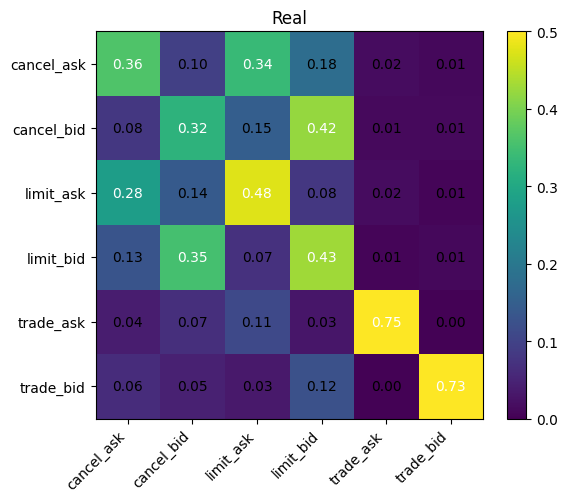

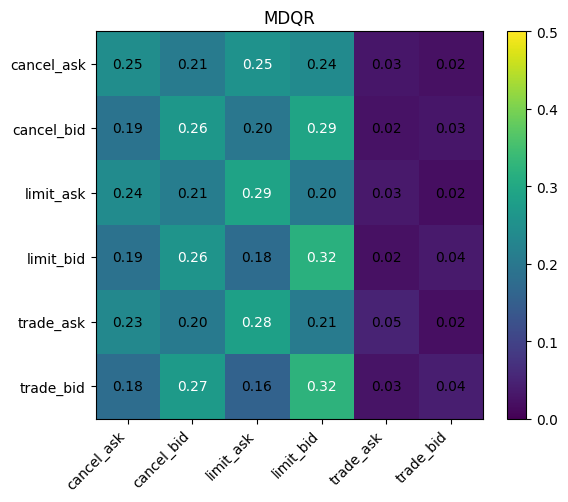

/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_7861/732236686.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


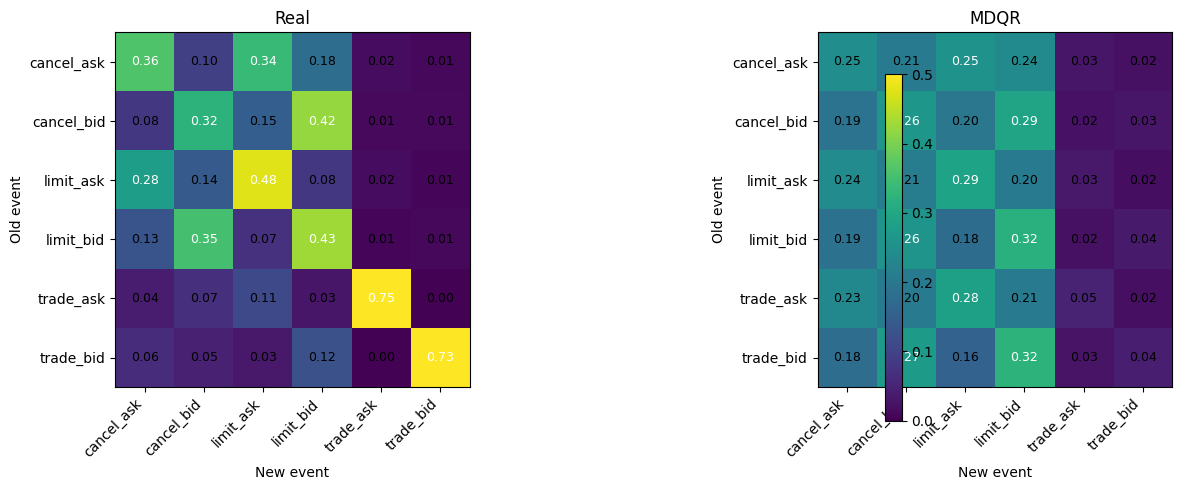

In [182]:
# 3) Plotting

def plot_transition(mat, title, vmin=0.0, vmax=0.5):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))

    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            color = "white" if val > 0.25 else "black"
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center", color=color, fontsize=10)

    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_transition_side_by_side(real_mat, sim_mat, vmin=0.0, vmax=0.5):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, mat, title in zip(
        axes,
        [real_mat, sim_mat],
        ["Real", "MDQR"]
    ):
        im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(mat.columns)))
        ax.set_yticks(range(len(mat.index)))

        ax.set_xticklabels(mat.columns, rotation=45, ha="right")
        ax.set_yticklabels(mat.index)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                color = "white" if val > 0.25 else "black"
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", color=color, fontsize=9)

        ax.set_title(title)
        ax.set_xlabel("New event")
        ax.set_ylabel("Old event")

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    plt.tight_layout()
    plt.show()


# individual plots
plot_transition(real_mat, "Real")
plot_transition(sim_mat, "MDQR")

# side-by-side plot 
plot_transition_side_by_side(real_mat, sim_mat)